C:\Users\marth\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


MARKET BASKET ANALYSIS

Total transactions: 10

Sample transactions:
Transaction 1: ['Bread', 'Milk', 'Eggs']
Transaction 2: ['Bread', 'Butter', 'Jam']
Transaction 3: ['Milk', 'Bread', 'Butter']

Binary matrix (first 5 rows):
   Bread  Butter  Cereal   Eggs    Jam   Milk
0   True   False   False   True  False   True
1   True    True   False  False   True  False
2   True    True   False  False  False   True
3   True    True   False   True  False   True
4  False   False    True   True  False   True

BASIC STATISTICS

Item frequencies:
Bread     8
Milk      8
Butter    6
Eggs      5
Jam       3
Cereal    2
dtype: int64

Average items per transaction: 3.20
Min items: 3
Max items: 4

APRIORI RESULTS

Frequent itemsets (support >= 0.3):
Total: 15
    support                          itemsets
0       0.8                frozenset({Bread})
1       0.6               frozenset({Butter})
2       0.5                 frozenset({Eggs})
3       0.3                  frozenset({Jam})
4       0.8        

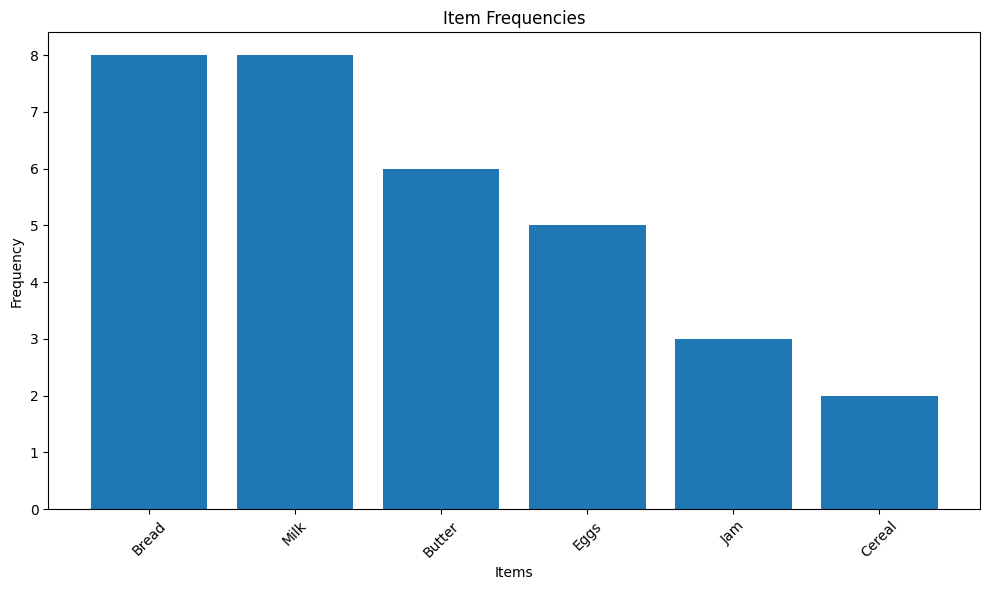

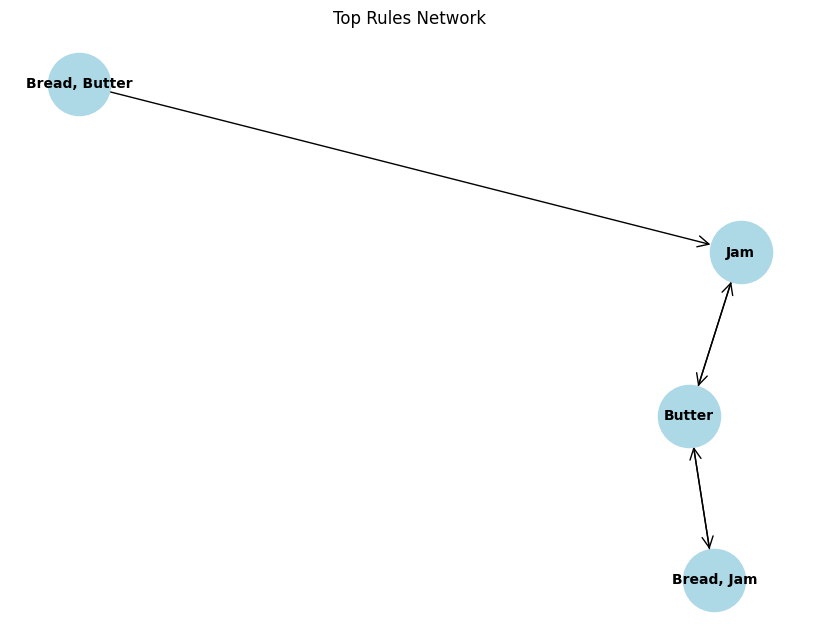


BUSINESS INTERPRETATION

What the rules mean:
• If a customer buys [item A], they are likely to also buy [item B]
• Lift > 1 means items are positively associated
• Confidence shows how often the rule holds true

Key Findings:
• Strongest association: Butter → Jam
  (Lift: 1.67)

Marketing Suggestions:
1. Store Layout: Place associated items near each other
2. Promotions: Offer discounts on pairs that are frequently bought together
3. Cross-selling: Train staff to suggest complementary items
4. Product placement: Create themed displays (e.g., breakfast section)

Results saved to 'simple_rules.csv'


In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx
# Part A: Data Preparation
print("="*60)
print("MARKET BASKET ANALYSIS")
print("="*60)
# Sample transaction data
transactions = [
    ['Bread', 'Milk', 'Eggs'],
    ['Bread', 'Butter', 'Jam'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Milk', 'Butter', 'Eggs'],
    ['Milk', 'Eggs', 'Cereal'],
    ['Bread', 'Eggs', 'Milk'],
    ['Butter', 'Jam', 'Bread'],
    ['Bread', 'Milk', 'Butter'],
    ['Milk', 'Cereal', 'Eggs'],
    ['Bread', 'Butter', 'Jam', 'Milk']
]
print(f"\nTotal transactions: {len(transactions)}")
print("\nSample transactions:")
for i in range(3):
    print(f"Transaction {i+1}: {transactions[i]}")
# Create binary matrix
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
print("\nBinary matrix (first 5 rows):")
print(df.head())
# Basic statistics
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)
# Item frequencies
item_freq = df.sum().sort_values(ascending=False)
print("\nItem frequencies:")
print(item_freq)
# Transaction lengths
trans_lengths = [len(t) for t in transactions]
print(f"\nAverage items per transaction: {np.mean(trans_lengths):.2f}")
print(f"Min items: {min(trans_lengths)}")
print(f"Max items: {max(trans_lengths)}")

# Part B: Apriori Algorithm
print("\n" + "="*60)
print("APRIORI RESULTS")
print("="*60)

# Find frequent itemsets
min_support = 0.3  # 30% of transactions
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
print(f"\nFrequent itemsets (support >= {min_support}):")
print(f"Total: {len(frequent_itemsets)}")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(f"\nAssociation rules generated: {len(rules)}")
print("\nAll rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Filter rules
rules = rules[rules['confidence'] >= 0.5]
print(f"\nRules with confidence >= 0.5: {len(rules)}")

# Part C: Top Rules
print("\n" + "="*60)
print("TOP RULES")
print("="*60)

# Top 5 by lift
print("\nTOP 5 RULES BY LIFT:")
top_lift = rules.nlargest(5, 'lift')
for i, (idx, row) in enumerate(top_lift.iterrows(), 1):
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{i}. {ante} → {cons}")
    print(f"   Support: {row['support']:.2f}, Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")

# Top 5 by confidence
print("\nTOP 5 RULES BY CONFIDENCE:")
top_conf = rules.nlargest(5, 'confidence')
for i, (idx, row) in enumerate(top_conf.iterrows(), 1):
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{i}. {ante} → {cons}")
    print(f"   Support: {row['support']:.2f}, Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")

# Simple visualization
plt.figure(figsize=(10, 6))
plt.bar(range(len(item_freq)), item_freq.values)
plt.xticks(range(len(item_freq)), item_freq.index, rotation=45)
plt.title('Item Frequencies')
plt.xlabel('Items')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Simple network graph
if len(rules) > 0:
    plt.figure(figsize=(8, 6))
    G = nx.DiGraph()
    
    # Add top 5 rules to graph
    for idx, row in top_lift.iterrows():
        ante = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))
        G.add_edge(ante, cons, weight=row['lift'])
        pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=2000, font_size=10, font_weight='bold',
            arrows=True, arrowstyle='->', arrowsize=20)
    plt.title('Top Rules Network')
    plt.show()

# Business Interpretation
print("\n" + "="*60)
print("BUSINESS INTERPRETATION")
print("="*60)

print("\nWhat the rules mean:")
print("• If a customer buys [item A], they are likely to also buy [item B]")
print("• Lift > 1 means items are positively associated")
print("• Confidence shows how often the rule holds true")
print("\nKey Findings:")
if len(rules) > 0:
    best_rule = rules.nlargest(1, 'lift').iloc[0]
    ante = ', '.join(list(best_rule['antecedents']))
    cons = ', '.join(list(best_rule['consequents']))
    print(f"• Strongest association: {ante} → {cons}")
    print(f"  (Lift: {best_rule['lift']:.2f})")
print("\nMarketing Suggestions:")
print("1. Store Layout: Place associated items near each other")
print("2. Promotions: Offer discounts on pairs that are frequently bought together")
print("3. Cross-selling: Train staff to suggest complementary items")
print("4. Product placement: Create themed displays (e.g., breakfast section)")

# Save results
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_csv('simple_rules.csv', index=False)
print("\nResults saved to 'simple_rules.csv'")





Dataset: Retail Market Basket

Transaction Data:
    Beer  Bread  Butter   Milk
0  False   True    True   True
1   True   True   False  False
2   True   True    True   True
3  False   True    True  False
4   True  False   False   True
5  False   True    True   True
6   True   True   False  False
7   True   True    True   True

Apriori Frequent Itemsets
   support                          itemsets
0    0.625                 frozenset({Beer})
1    0.875                frozenset({Bread})
2    0.625               frozenset({Butter})
3    0.625                 frozenset({Milk})
4    0.500          frozenset({Bread, Beer})
5    0.375           frozenset({Milk, Beer})
6    0.625        frozenset({Bread, Butter})
7    0.500          frozenset({Bread, Milk})
8    0.500         frozenset({Milk, Butter})
9    0.500  frozenset({Bread, Milk, Butter})

Apriori Rules
                   antecedents                 consequents  support  \
0            frozenset({Beer})          frozenset({Bread})    0

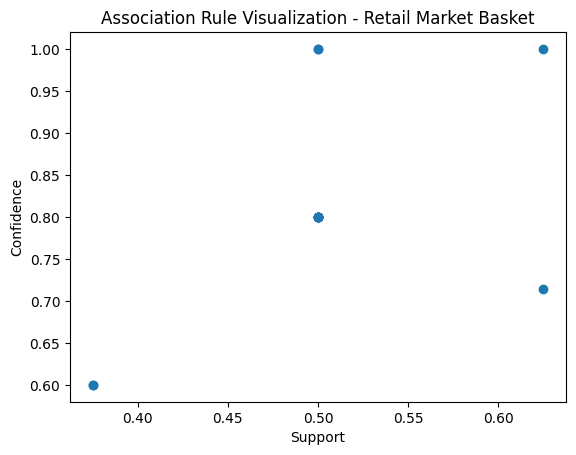

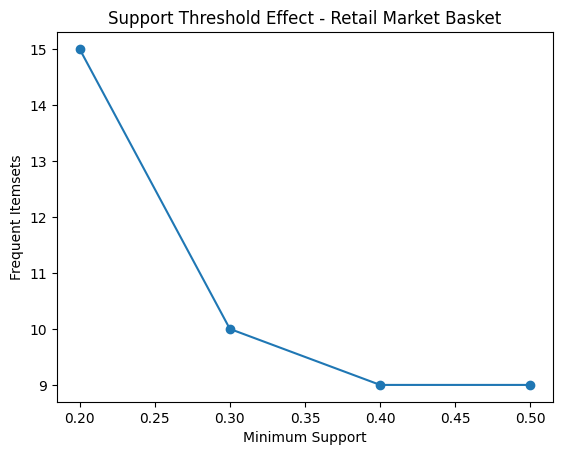


Dataset: Healthcare Symptoms

Transaction Data:
    Cold  Cough  Fever
0   True   True   True
1   True  False   True
2   True   True  False
3  False   True   True
4   True   True   True
5   True  False  False

Apriori Frequent Itemsets
    support                         itemsets
0  0.833333                frozenset({Cold})
1  0.666667               frozenset({Cough})
2  0.666667               frozenset({Fever})
3  0.500000         frozenset({Cough, Cold})
4  0.500000         frozenset({Cold, Fever})
5  0.500000        frozenset({Cough, Fever})
6  0.333333  frozenset({Cough, Cold, Fever})

Apriori Rules
                 antecedents         consequents   support  confidence   lift
0         frozenset({Cough})   frozenset({Cold})  0.500000    0.750000  0.900
1          frozenset({Cold})  frozenset({Cough})  0.500000    0.600000  0.900
2          frozenset({Cold})  frozenset({Fever})  0.500000    0.600000  0.900
3         frozenset({Fever})   frozenset({Cold})  0.500000    0.750000  0.90

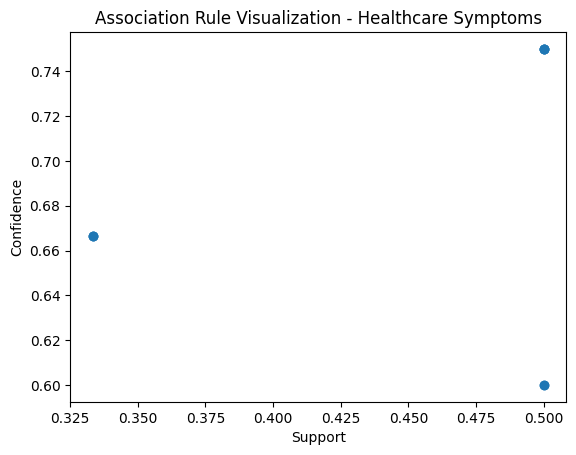

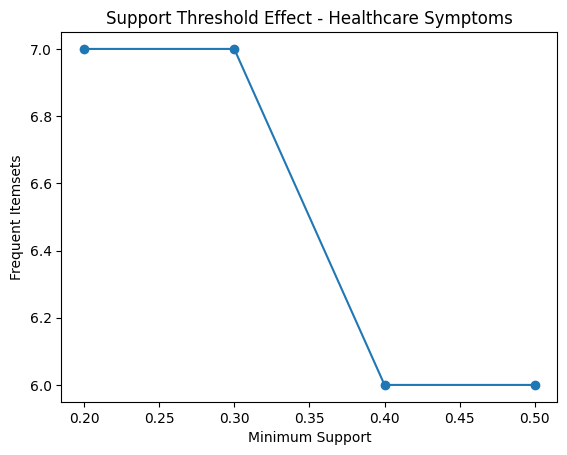

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules


# ------------------------------------------------
# 1. Function to run Association Rule Mining
# ------------------------------------------------
def run_association_mining(dataset, name):

    print("\n====================================")
    print("Dataset:", name)
    print("====================================")

    # Convert dataset to dataframe
    te = TransactionEncoder()
    te_array = te.fit(dataset).transform(dataset)
    df = pd.DataFrame(te_array, columns=te.columns_)

    print("\nTransaction Data:")
    print(df)

    # ------------------------------------------------
    # 2. Apriori Algorithm
    # ------------------------------------------------
    apriori_freq = apriori(df, min_support=0.3, use_colnames=True)

    apriori_rules = association_rules(
        apriori_freq,
        metric="confidence",
        min_threshold=0.6
    )

    print("\nApriori Frequent Itemsets")
    print(apriori_freq)

    print("\nApriori Rules")
    print(apriori_rules[['antecedents','consequents','support','confidence','lift']])


    # ------------------------------------------------
    # 3. FP-Growth Algorithm
    # ------------------------------------------------
    fp_freq = fpgrowth(df, min_support=0.3, use_colnames=True)

    fp_rules = association_rules(
        fp_freq,
        metric="confidence",
        min_threshold=0.6
    )

    print("\nFP-Growth Frequent Itemsets")
    print(fp_freq)

    print("\nFP-Growth Rules")
    print(fp_rules[['antecedents','consequents','support','confidence','lift']])


    # ------------------------------------------------
    # 4. Compare Algorithms
    # ------------------------------------------------
    print("\nAlgorithm Comparison")

    print("Apriori Itemsets:", len(apriori_freq))
    print("FP-Growth Itemsets:", len(fp_freq))

    print("Apriori Rules:", len(apriori_rules))
    print("FP-Growth Rules:", len(fp_rules))


    # ------------------------------------------------
    # 5. Rule Pruning
    # ------------------------------------------------
    pruned_rules = apriori_rules[
        (apriori_rules['lift'] > 1) &
        (apriori_rules['confidence'] > 0.7)
    ]

    print("\nPruned Rules")
    print(pruned_rules[['antecedents','consequents','support','confidence','lift']])


    # ------------------------------------------------
    # 6. Visualization Dashboard
    # ------------------------------------------------
    plt.scatter(
        apriori_rules['support'],
        apriori_rules['confidence']
    )

    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.title("Association Rule Visualization - " + name)

    plt.show()


    # ------------------------------------------------
    # 7. Support Threshold Analysis
    # ------------------------------------------------
    supports = [0.2,0.3,0.4,0.5]
    itemsets_count = []

    for s in supports:
        freq = apriori(df, min_support=s, use_colnames=True)
        itemsets_count.append(len(freq))

    plt.plot(supports,itemsets_count,marker='o')

    plt.xlabel("Minimum Support")
    plt.ylabel("Frequent Itemsets")

    plt.title("Support Threshold Effect - " + name)

    plt.show()


# ------------------------------------------------
# 8. Retail Dataset
# ------------------------------------------------
retail_dataset = [
    ['Milk','Bread','Butter'],
    ['Beer','Bread'],
    ['Milk','Bread','Beer','Butter'],
    ['Bread','Butter'],
    ['Milk','Beer'],
    ['Milk','Bread','Butter'],
    ['Bread','Beer'],
    ['Milk','Bread','Beer','Butter']
]


# ------------------------------------------------
# 9. Healthcare Dataset
# ------------------------------------------------
healthcare_dataset = [
    ['Fever','Cough','Cold'],
    ['Fever','Cold'],
    ['Cough','Cold'],
    ['Fever','Cough'],
    ['Fever','Cough','Cold'],
    ['Cold']
]


# ------------------------------------------------
# 10. Run Program for Different Domains
# ------------------------------------------------
run_association_mining(retail_dataset, "Retail Market Basket")

run_association_mining(healthcare_dataset, "Healthcare Symptoms")